In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re

df = pd.read_csv("jumia_reviews_dataset.csv")
print(f"Total Reviews Loaded: {len(df)}")


nltk.download('stopwords', quiet=True)


stop_words = set(stopwords.words('english'))


naija_stops = [
    'na', 'dey', 'go', 'una', 'abeg', 'seff', 'sha',
    'make', 'don', 'abi', 'wetin', 'wey'
]
stop_words.update(naija_stops)


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)


df['Cleaned_Content'] = df['Review_Content'].apply(clean_text)

print("Data Cleaning Complete. Sample:")
print(df[['Product_Name', 'Cleaned_Content']].head())


Total Reviews Loaded: 2995
Data Cleaning Complete. Sample:
  Product_Name       Cleaned_Content
0  Samsung_A06         amazing phone
1  Samsung_A06  perfect try work ram
2  Samsung_A06                      
3  Samsung_A06               perfect
4  Samsung_A06    descriptions right


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from textblob import TextBlob


def get_sentiment_label(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'


df['Sentiment_Label'] = df['Cleaned_Content'].apply(get_sentiment_label)


training_data = df[df['Sentiment_Label'] != 'Neutral']

print("Training samples:", len(training_data))


X = training_data['Cleaned_Content']
y = training_data['Sentiment_Label']


vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)


nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


y_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


all_vec = vectorizer.transform(df['Cleaned_Content'])
df['NB_Predicted_Sentiment'] = nb_model.predict(all_vec)

print(df[['Cleaned_Content', 'NB_Predicted_Sentiment']].head())


Training samples: 2682
Naive Bayes Accuracy: 0.9813780260707635

Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.92      0.81        24
    Positive       1.00      0.98      0.99       513

    accuracy                           0.98       537
   macro avg       0.86      0.95      0.90       537
weighted avg       0.98      0.98      0.98       537

        Cleaned_Content NB_Predicted_Sentiment
0         amazing phone               Positive
1  perfect try work ram               Positive
2                                     Positive
3               perfect               Positive
4    descriptions right               Positive


In [15]:
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# 1. SETUP LDA MODEL
lda_model = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method='batch'
)

lda_output = lda_model.fit_transform(all_vec)

# 2. DISPLAY TOP WORDS PER TOPIC
def display_topics(model, feature_names, no_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-no_top_words - 1:-1]
        ]
        topics[f"Topic {topic_idx}"] = top_words
    return topics

tf_feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda_model, tf_feature_names, 10)

print("Discovered Topics (Aspects):")
for topic, words in topics.items():
    print(f"{topic}: {', '.join(words)}")

# 3. ASSIGN DOMINANT TOPIC TO EACH REVIEW
df['Topic_ID'] = lda_output.argmax(axis=1)

# 4. HUMAN-READABLE ASPECT NAMES
topic_map = {
    0: "Delivery & Order Experience",
    1: "General Satisfaction",
    2: "Device Performance (Battery/Camera)"
}

df['Aspect'] = df['Topic_ID'].map(topic_map).fillna("Other")

# Preview
df[['Cleaned_Content', 'Aspect']].head()


Discovered Topics (Aspects):
Topic 0: good, exactly, keep, perfect, light, ordered, bought, got, smart, described
Topic 1: product, perfectly, love, good, working, great, gift, use, free, data
Topic 2: phone, nice, good, battery, really, camera, beautiful, recommend, lovely, quality


,Cleaned_Content,Aspect
0,amazing phone,Device Performance (Battery/Camera)
1,perfect try work ram,Delivery & Order Experience
2,,Delivery & Order Experience
3,perfect,Delivery & Order Experience
4,descriptions right,Device Performance (Battery/Camera)



--- CHAPTER 4: COMPARATIVE ANALYSIS RESULT ---
Aspect        Delivery & Order Experience  \
Product_Name                                
Redmi_A5                             99.6   
Samsung_A06                          99.3   
Tecno_POP10                          99.1   

Aspect        Device Performance (Battery/Camera)  General Satisfaction  
Product_Name                                                             
Redmi_A5                                     98.6                  98.3  
Samsung_A06                                  97.6                  91.3  
Tecno_POP10                                  83.4                  98.4  


Matplotlib is building the font cache; this may take a moment.


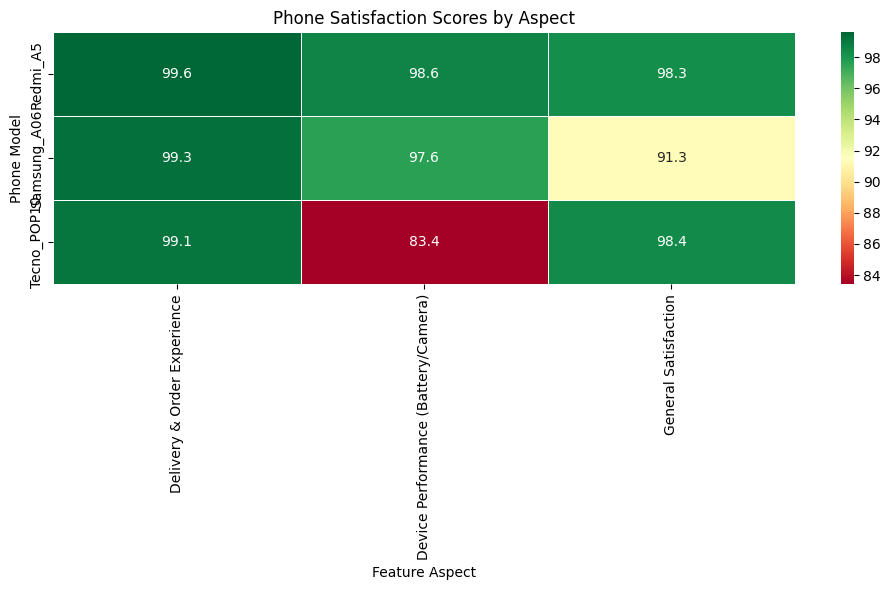


--- SYSTEM RECOMMENDATION ---
User Request: 'I want a phone with good battery and camera.'
System Analysis: Based on 2995 reviews
👉 RECOMMENDATION: Redmi_A5
Reason: Highest satisfaction score (98.6%) for Device Performance (Battery/Camera)


In [ ]:
# --- STEP 4: RECOMMENDATION ENGINE & VISUALIZATION ---

# 1. APPLY HUMAN-READABLE ASPECT NAMES
topic_map = {
    0: "Delivery & Order Experience",
    1: "General Satisfaction",
    2: "Device Performance (Battery/Camera)"
}

df['Aspect'] = df['Topic_ID'].map(topic_map).fillna("Other")



# Convert Naive Bayes predictions to numeric
df['Sentiment_Score'] = df['NB_Predicted_Sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

# Drop Neutral or missing values
df_scoring = df.dropna(subset=['Sentiment_Score']).copy()

# Formula: (Positive / Total) * 100
final_table = (
    df_scoring
    .groupby(['Product_Name', 'Aspect'])['Sentiment_Score']
    .mean()
    .unstack()
    .fillna(0) * 100
).round(1)

print("\n--- CHAPTER 4: COMPARATIVE ANALYSIS RESULT ---")
print(final_table)


# 3. VISUALIZATION (HEATMAP)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    final_table,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    linewidths=0.5
)
plt.title("Phone Satisfaction Scores by Aspect")
plt.ylabel("Phone Model")
plt.xlabel("Feature Aspect")
plt.tight_layout()
plt.show()


# 4. FINAL SYSTEM RECOMMENDATION
target_aspect = "Device Performance (Battery/Camera)"

if target_aspect in final_table.columns:
    best_phone = final_table[target_aspect].idxmax()
    best_score = final_table[target_aspect].max()

    print("\n--- SYSTEM RECOMMENDATION ---")
    print("User Request: 'I want a phone with good battery and camera.'")
    print(f"System Analysis: Based on {len(df_scoring)} reviews")
    print(f"👉 RECOMMENDATION: {best_phone}")
    print(f"Reason: Highest satisfaction score ({best_score}%) for {target_aspect}")
else:
    print("Target aspect not found. Please check topic mapping.")
